Environment setup

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from openai import OpenAI
from collections import Counter
import shutil

load_dotenv()

print("✅ All imports loaded successfully")
print("✅ OpenAI API Key loaded:", os.getenv("OPENAI_API_KEY")[:8], "...")

✅ All imports loaded successfully
✅ OpenAI API Key loaded: sk-proj- ...


Transcribe audio

In [2]:
from pydub import AudioSegment

client = OpenAI()

audio_path = r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\The_Blueprint_For_Trustworthy_AI.m4a"
transcript_folder = Path(r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\transcripts")
transcript_folder.mkdir(exist_ok=True)

print("⏳ Loading audio file...")
audio = AudioSegment.from_file(audio_path, format="m4a")

chunk_duration_ms = 10 * 60 * 1000
chunks_audio = [audio[i:i+chunk_duration_ms] for i in range(0, len(audio), chunk_duration_ms)]
print(f"✅ Split into {len(chunks_audio)} audio chunks")

full_transcript = ""
for i, chunk in enumerate(chunks_audio):
    print(f"⏳ Transcribing chunk {i+1}/{len(chunks_audio)}...")
    chunk_path = transcript_folder / f"temp_chunk_{i}.mp3"
    chunk.export(chunk_path, format="mp3")
    with open(chunk_path, "rb") as f:
        result = client.audio.transcriptions.create(model="whisper-1", file=f, response_format="text")
    full_transcript += result + " "
    chunk_path.unlink()

output_path = transcript_folder / "The_Blueprint_For_Trustworthy_AI.txt"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(full_transcript.strip())

print(f"✅ Transcript saved to: {output_path}")

⏳ Loading audio file...
✅ Split into 2 audio chunks
⏳ Transcribing chunk 1/2...
⏳ Transcribing chunk 2/2...
✅ Transcript saved to: C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\transcripts\The_Blueprint_For_Trustworthy_AI.txt


Cell 2 — Transcribe Audio

In [3]:
from pydub import AudioSegment

client = OpenAI()

audio_path = r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\The_Blueprint_For_Trustworthy_AI.m4a"
transcript_folder = Path(r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\transcripts")
transcript_folder.mkdir(exist_ok=True)

print("⏳ Loading audio file...")
audio = AudioSegment.from_file(audio_path, format="m4a")

chunk_duration_ms = 10 * 60 * 1000
chunks_audio = [audio[i:i+chunk_duration_ms] for i in range(0, len(audio), chunk_duration_ms)]
print(f"✅ Split into {len(chunks_audio)} audio chunks")

full_transcript = ""
for i, chunk in enumerate(chunks_audio):
    print(f"⏳ Transcribing chunk {i+1}/{len(chunks_audio)}...")
    chunk_path = transcript_folder / f"temp_chunk_{i}.mp3"
    chunk.export(chunk_path, format="mp3")
    with open(chunk_path, "rb") as f:
        result = client.audio.transcriptions.create(model="whisper-1", file=f, response_format="text")
    full_transcript += result + " "
    chunk_path.unlink()

output_path = transcript_folder / "The_Blueprint_For_Trustworthy_AI.txt"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(full_transcript.strip())

print(f"✅ Transcript saved to: {output_path}")

⏳ Loading audio file...
✅ Split into 2 audio chunks
⏳ Transcribing chunk 1/2...
⏳ Transcribing chunk 2/2...
✅ Transcript saved to: C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\transcripts\The_Blueprint_For_Trustworthy_AI.txt


Cell 3 — Load, Chunk & Embed

In [4]:
# ── Load PDF ──────────────────────────────────────────────────────────────────
pdf_loader = PyPDFLoader(r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\Living_Repository_AI_Literacy_Practices_Update_16042025_UqmogIt2HpLVokdcuzJL4mDvHk8_112203.pdf")
eu_docs = pdf_loader.load()
for doc in eu_docs:
    doc.metadata["source_type"] = "eu_ai_act"
    doc.metadata["source_name"] = "EU AI Act"
print(f"✅ PDF pages loaded: {len(eu_docs)}")

# ── Load Podcast Transcript ───────────────────────────────────────────────────
transcript_loader = TextLoader(r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\transcripts\The_Blueprint_For_Trustworthy_AI.txt", encoding="utf-8")
transcript_docs = transcript_loader.load()
for doc in transcript_docs:
    doc.metadata["source_type"] = "podcast"
    doc.metadata["source_name"] = "The Blueprint For Trustworthy AI"
print(f"✅ Podcast pages loaded: {len(transcript_docs)}")

# ── Chunk ─────────────────────────────────────────────────────────────────────
documents = eu_docs + transcript_docs
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50, add_start_index=True)
chunks = splitter.split_documents(documents)
clean_chunks = [c for c in chunks if isinstance(c, Document) and c.page_content.strip() != ""]
print(f"✅ Clean chunks ready: {len(clean_chunks)}")

# ── Embed & Store ─────────────────────────────────────────────────────────────
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma.from_documents(
    documents=clean_chunks,
    embedding=embeddings,
    persist_directory=r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\chroma_db",
    collection_name="rag_lab"
)
print(f"✅ Vectorstore ready with {vectorstore._collection.count()} chunks")

✅ PDF pages loaded: 73
✅ Podcast pages loaded: 1
✅ Clean chunks ready: 570
✅ Vectorstore ready with 570 chunks


Generate Embeddings and Initial Retrieval

In [5]:
# ── Cell 4 — Step 2: Generate Embeddings & Initial Retrieval ──────────────────

# ── Reload Vectorstore from Disk ──────────────────────────────────────────────
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Chroma(
    persist_directory=r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\chroma_db",
    embedding_function=embeddings,
    collection_name="rag_lab"
)
print(f"✅ Vectorstore reloaded with {vectorstore._collection.count()} chunks")

# ── Basic Retriever ───────────────────────────────────────────────────────────
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

# ── Test Queries ──────────────────────────────────────────────────────────────
test_queries = [
    "What are the requirements for high-risk AI systems?",
    "What makes AI trustworthy?",
    "How should AI systems be transparent?"
]

for query in test_queries:
    print(f"\n🔍 Query: {query}")
    print("-" * 60)
    results = retriever.invoke(query)
    for i, doc in enumerate(results):
        print(f"  Result {i+1} | Source: {doc.metadata.get('source_type')} | {doc.metadata.get('source_name')}")
        print(f"  {doc.page_content[:200]}")
        print()

C:\Users\pbiai\AppData\Local\Temp\ipykernel_17200\4254795027.py:6: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


✅ Vectorstore reloaded with 570 chunks

🔍 Query: What are the requirements for high-risk AI systems?
------------------------------------------------------------
  Result 1 | Source: eu_ai_act | EU AI Act
  The AI Scanner automatically classifies AI systems into categories defined by the EU AI Act: 
• High-risk AI: Systems with significant implications for safety, fundamental rights, or regulatory 
compl

  Result 2 | Source: eu_ai_act | EU AI Act
  In addition, the organisation is provider of AI systems which can be classified, according to our current 
assessment, as high-risk, as they qualify as medical devices and fall down the high -risk req

  Result 3 | Source: eu_ai_act | EU AI Act
  on the level of risk they pose to health, safety, and fundamental rights. High-risk AI systems are subject 
to stringent regulatory requirements to ensure their safety and compliance. 
Content Generat

  Result 4 | Source: eu_ai_act | EU AI Act
  health, safety, and fundamental rights as defined in

Step 3: Implement Relevance Scoring via an LLM (Optional - Advanced)

Use LLM (i.e. chatgpt with a prompt) to score each retrieved chunk's relevance to the query

In [6]:
# ── Cell 5 — Step 3.1: Relevance Scoring via LLM ─────────────────────────────

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def score_chunk_relevance(query, chunk_content):
    prompt = f"""You are a relevance scoring assistant.
    
Query: {query}
Chunk: {chunk_content}

Score how relevant this chunk is to the query on a scale from 0 to 10.
Return ONLY a number between 0 and 10. No explanation."""

    response = llm.invoke(prompt)
    try:
        score = float(response.content.strip())
    except:
        score = 0.0
    return score

# ── Test on first query ───────────────────────────────────────────────────────
query = "What makes AI trustworthy?"
results = retriever.invoke(query)

print(f"🔍 Query: {query}\n")
for i, doc in enumerate(results):
    score = score_chunk_relevance(query, doc.page_content)
    print(f"  Chunk {i+1} | Score: {score}/10 | Source: {doc.metadata.get('source_type')}")
    print(f"  {doc.page_content[:200]}")
    print()
    

🔍 Query: What makes AI trustworthy?

  Chunk 1 | Score: 9.0/10 | Source: podcast
  trustworthy AI is really about proving that the people behind the curtain have done their homework. That is the takeaway. So here's the challenge for you listening. Next time you interact with a syste

  Chunk 2 | Score: 8.0/10 | Source: podcast
  system. It's not just the code. It's the code, plus the humans, plus the laws, plus the environment. But there's a philosophical nugget at the end of the document that really stuck with me. It says tr

  Chunk 3 | Score: 6.0/10 | Source: eu_ai_act
  trust to ensure that we capture any challenges with the use of the t echnology. We address inaccuracy 
issues through the critical thinking skills of our teams in an environment of psychological safet

  Chunk 4 | Score: 6.0/10 | Source: eu_ai_act
  rapidly evolving nature of AI technology. Additionally, there is an ongoing need to counter misinformation 
and foster trust in AI systems while continuing to mitigate t

Combine similarity score with relevance score

In [7]:
# ── Cell 6 — Step 3.2: Combine Similarity + Relevance Score ──────────────────

def combined_retrieval(query, retriever, top_k=5):
    # ── Get chunks with similarity scores ────────────────────────────────────
    results_with_scores = vectorstore.similarity_search_with_score(query, k=top_k)
    
    combined_results = []
    for doc, similarity_score in results_with_scores:
        # ── Get LLM relevance score ───────────────────────────────────────────
        relevance_score = score_chunk_relevance(query, doc.page_content)
        
        # ── Normalize similarity score (chromadb returns distance: lower = better)
        normalized_similarity = 1 - similarity_score
        
        # ── Combine both scores (50/50 weight) ────────────────────────────────
        final_score = (normalized_similarity * 0.5) + (relevance_score / 10 * 0.5)
        
        combined_results.append((doc, similarity_score, relevance_score, final_score))
    
    # ── Reorder by final score ────────────────────────────────────────────────
    combined_results.sort(key=lambda x: x[3], reverse=True)
    return combined_results

# ── Test ──────────────────────────────────────────────────────────────────────
query = "What makes AI trustworthy?"
print(f"🔍 Query: {query}\n")

reranked_results = combined_retrieval(query, retriever)

for i, (doc, sim_score, rel_score, final_score) in enumerate(reranked_results):
    print(f"  Chunk {i+1} | Similarity: {1-sim_score:.2f} | LLM Score: {rel_score}/10 | Final: {final_score:.2f}")
    print(f"  Source: {doc.metadata.get('source_type')}")
    print(f"  {doc.page_content[:200]}")
    print()

🔍 Query: What makes AI trustworthy?

  Chunk 1 | Similarity: 0.29 | LLM Score: 9.0/10 | Final: 0.59
  Source: podcast
  trustworthy AI is really about proving that the people behind the curtain have done their homework. That is the takeaway. So here's the challenge for you listening. Next time you interact with a syste

  Chunk 2 | Similarity: 0.28 | LLM Score: 9.0/10 | Final: 0.59
  Source: podcast
  system. It's not just the code. It's the code, plus the humans, plus the laws, plus the environment. But there's a philosophical nugget at the end of the document that really stuck with me. It says tr

  Chunk 3 | Similarity: 0.21 | LLM Score: 6.0/10 | Final: 0.40
  Source: eu_ai_act
  trust to ensure that we capture any challenges with the use of the t echnology. We address inaccuracy 
issues through the critical thinking skills of our teams in an environment of psychological safet

  Chunk 4 | Similarity: 0.19 | LLM Score: 6.0/10 | Final: 0.40
  Source: eu_ai_act
  rapidly evolving natu

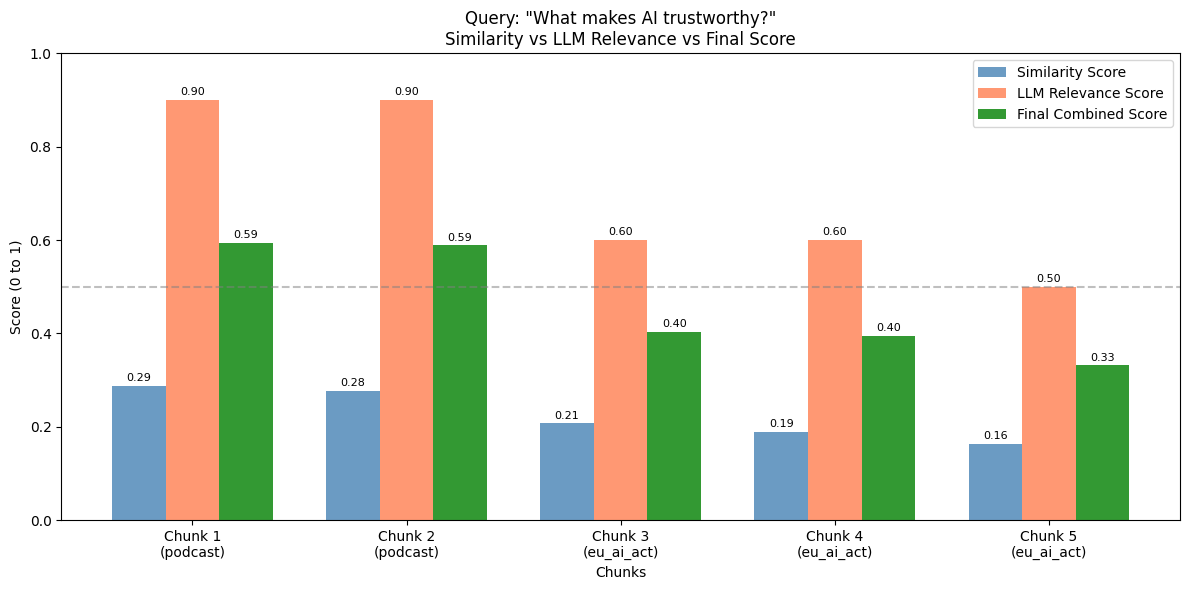

In [8]:
# ── Visualize Similarity vs LLM Relevance Score ───────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

query = "What makes AI trustworthy?"
reranked_results = combined_retrieval(query, retriever)

# ── Extract data ──────────────────────────────────────────────────────────────
labels = [f"Chunk {i+1}\n({doc.metadata.get('source_type')})" for i, (doc, _, _, _) in enumerate(reranked_results)]
similarity_scores = [1 - sim for _, sim, _, _ in reranked_results]
llm_scores = [rel / 10 for _, _, rel, _ in reranked_results]
final_scores = [final for _, _, _, final in reranked_results]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, similarity_scores, width, label='Similarity Score', color='steelblue', alpha=0.8)
bars2 = ax.bar(x, llm_scores, width, label='LLM Relevance Score', color='coral', alpha=0.8)
bars3 = ax.bar(x + width, final_scores, width, label='Final Combined Score', color='green', alpha=0.8)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('Chunks')
ax.set_ylabel('Score (0 to 1)')
ax.set_title(f'Query: "{query}"\nSimilarity vs LLM Relevance vs Final Score')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 threshold')

# ── Value labels on bars ──────────────────────────────────────────────────────
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=8)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

Reorder results based on combined score

In [9]:
# ── Cell 7 — Step 3.3: Reorder Results Based on Combined Score ────────────────

def rerank_by_combined_score(query, k=5):
    results_with_scores = vectorstore.similarity_search_with_score(query, k=k)
    
    combined_results = []
    for doc, similarity_score in results_with_scores:
        relevance_score = score_chunk_relevance(query, doc.page_content)
        normalized_similarity = 1 - similarity_score
        final_score = (normalized_similarity * 0.5) + (relevance_score / 10 * 0.5)
        combined_results.append((doc, normalized_similarity, relevance_score, final_score))
    
    # ── Reorder by final score ────────────────────────────────────────────────
    combined_results.sort(key=lambda x: x[3], reverse=True)
    return combined_results

# ── Test all queries ──────────────────────────────────────────────────────────
test_queries = [
    "What are the requirements for high-risk AI systems?",
    "What makes AI trustworthy?",
    "How should AI systems be transparent?"
]

for query in test_queries:
    print(f"\n🔍 Query: {query}")
    print("-" * 60)
    reranked = rerank_by_combined_score(query)
    for i, (doc, sim, rel, final) in enumerate(reranked):
        print(f"  Rank {i+1} | Similarity: {sim:.2f} | LLM: {rel}/10 | Final: {final:.2f} | Source: {doc.metadata.get('source_type')}")
        print(f"  {doc.page_content[:200]}")
        print()


🔍 Query: What are the requirements for high-risk AI systems?
------------------------------------------------------------
  Rank 1 | Similarity: 0.40 | LLM: 8.0/10 | Final: 0.60 | Source: eu_ai_act
  The AI Scanner automatically classifies AI systems into categories defined by the EU AI Act: 
• High-risk AI: Systems with significant implications for safety, fundamental rights, or regulatory 
compl

  Rank 2 | Similarity: 0.29 | LLM: 8.0/10 | Final: 0.55 | Source: eu_ai_act
  health, safety, and fundamental rights as defined in the EU AI Act.  
According to our current assessment, our AI systems are not high-risk, but we evaluate high-risk systems 
and recommend mitigation

  Rank 3 | Similarity: 0.38 | LLM: 7.0/10 | Final: 0.54 | Source: eu_ai_act
  In addition, the organisation is provider of AI systems which can be classified, according to our current 
assessment, as high-risk, as they qualify as medical devices and fall down the high -risk req

  Rank 4 | Similarity: 0.35 | LLM: 6.

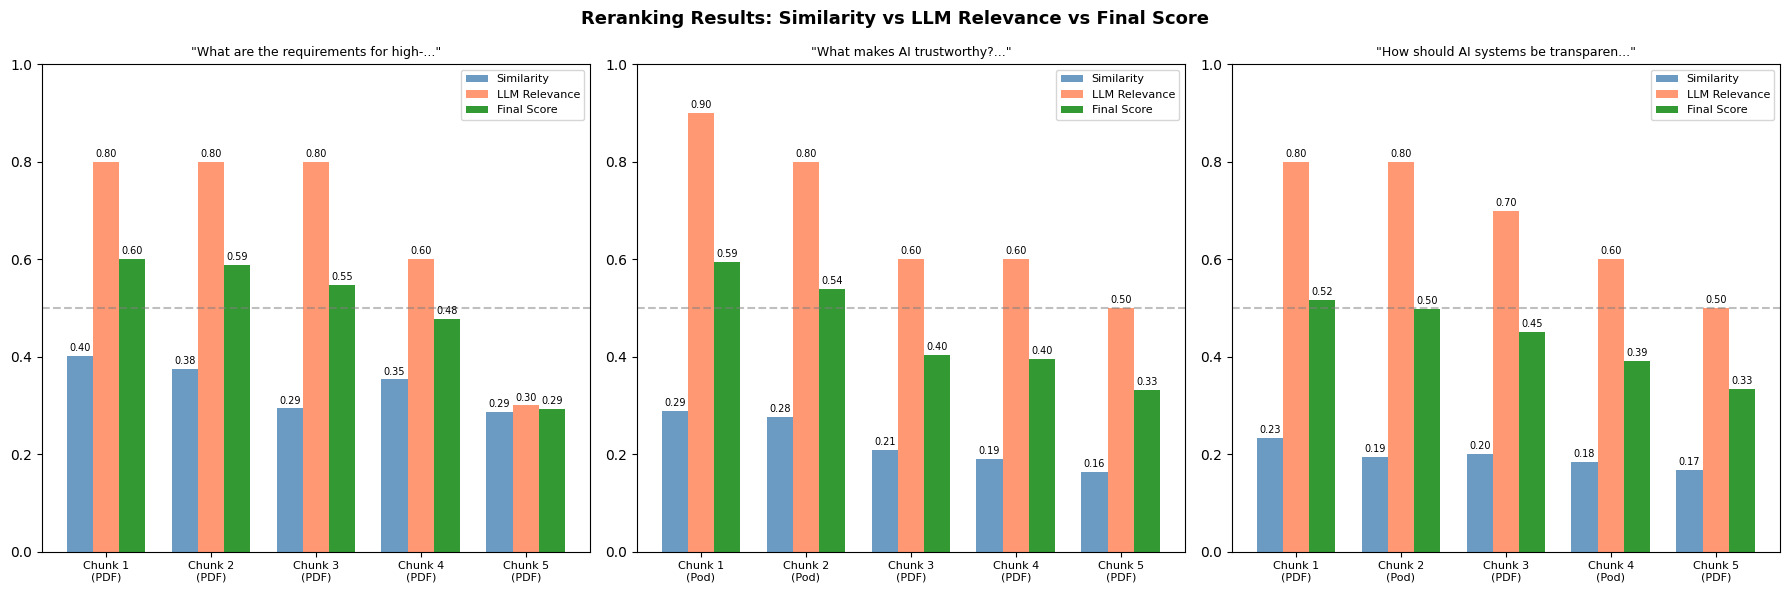

In [10]:
# ── Cell 7b — Save and run visualization ─────────────────────────────────────

viz_code = '''
import matplotlib.pyplot as plt
import numpy as np

test_queries = [
    "What are the requirements for high-risk AI systems?",
    "What makes AI trustworthy?",
    "How should AI systems be transparent?"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, query in zip(axes, test_queries):
    reranked = rerank_by_combined_score(query)
    labels = [f"Chunk {i+1}\\n({doc.metadata.get('source_type').replace('eu_ai_act', 'PDF').replace('podcast', 'Pod')})" for i, (doc, _, _, _) in enumerate(reranked)]
    similarity_scores = [sim for _, sim, _, _ in reranked]
    llm_scores = [rel / 10 for _, _, rel, _ in reranked]
    final_scores = [final for _, _, _, final in reranked]
    x = np.arange(len(labels))
    width = 0.25
    bars1 = ax.bar(x - width, similarity_scores, width, label="Similarity", color="steelblue", alpha=0.8)
    bars2 = ax.bar(x, llm_scores, width, label="LLM Relevance", color="coral", alpha=0.8)
    bars3 = ax.bar(x + width, final_scores, width, label="Final Score", color="green", alpha=0.8)
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.2f}", ha="center", fontsize=7)
    ax.set_title(f\'"{query[:35]}..."\', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax.legend(fontsize=8)

plt.suptitle("Reranking Results: Similarity vs LLM Relevance vs Final Score", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
'''

exec(viz_code)

Step 4: Implement Reranker (Cohere or Cross-Encoder) (Optional - Advanced)
Objective: Use a dedicated reranker model for better performance.

Use Cohere Rerank API or sentence-transformers cross-encoder

In [11]:
# ── Cell 8 — Step 4: Cross-Encoder Reranker ──────────────────────────────────

from sentence_transformers import CrossEncoder

# ── Load Cross-Encoder model ──────────────────────────────────────────────────
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("✅ Cross-Encoder model loaded")

def rerank_with_cross_encoder(query, k=5):
    # ── Get initial chunks from vectorstore ───────────────────────────────────
    initial_results = vectorstore.similarity_search(query, k=k)
    
    # ── Score each chunk with cross-encoder ───────────────────────────────────
    pairs = [[query, doc.page_content] for doc in initial_results]
    scores = cross_encoder.predict(pairs)
    
    # ── Combine and reorder ───────────────────────────────────────────────────
    reranked = sorted(zip(initial_results, scores), key=lambda x: x[1], reverse=True)
    return reranked

# ── Test ──────────────────────────────────────────────────────────────────────
query = "What makes AI trustworthy?"
print(f"\n🔍 Query: {query}\n")

results = rerank_with_cross_encoder(query)

for i, (doc, score) in enumerate(results):
    print(f"  Rank {i+1} | Cross-Encoder Score: {score:.4f} | Source: {doc.metadata.get('source_type')}")
    print(f"  {doc.page_content[:200]}")
    print()

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Cross-Encoder model loaded

🔍 Query: What makes AI trustworthy?

  Rank 1 | Cross-Encoder Score: 6.4020 | Source: podcast
  system. It's not just the code. It's the code, plus the humans, plus the laws, plus the environment. But there's a philosophical nugget at the end of the document that really stuck with me. It says tr

  Rank 2 | Cross-Encoder Score: 6.3307 | Source: podcast
  trustworthy AI is really about proving that the people behind the curtain have done their homework. That is the takeaway. So here's the challenge for you listening. Next time you interact with a syste

  Rank 3 | Cross-Encoder Score: 0.9299 | Source: eu_ai_act
  rapidly evolving nature of AI technology. Additionally, there is an ongoing need to counter misinformation 
and foster trust in AI systems while continuing to mitigate the risks of bias, privacy viola

  Rank 4 | Cross-Encoder Score: -2.0267 | Source: eu_ai_act
  trust to ensure that we capture any challenges with the use of the t echnology. We add

Rerank initial retrieval results

In [12]:
# ── Cell 9 — Rerank Initial Retrieval Results (All Queries) ───────────────────

test_queries = [
    "What are the requirements for high-risk AI systems?",
    "What makes AI trustworthy?",
    "How should AI systems be transparent?"
]

for query in test_queries:
    print(f"\n🔍 Query: {query}")
    print("-" * 60)
    
    # ── Before reranking (raw similarity) ────────────────────────────────────
    initial_results = vectorstore.similarity_search_with_score(query, k=5)
    print("  BEFORE reranking (similarity order):")
    for i, (doc, score) in enumerate(initial_results):
        print(f"    {i+1}. Similarity: {1-score:.2f} | Source: {doc.metadata.get('source_type')} | {doc.page_content[:100]}")
    
    # ── After reranking (cross-encoder) ───────────────────────────────────────
    reranked_results = rerank_with_cross_encoder(query)
    print("\n  AFTER reranking (cross-encoder order):")
    for i, (doc, score) in enumerate(reranked_results):
        print(f"    {i+1}. Score: {score:.2f} | Source: {doc.metadata.get('source_type')} | {doc.page_content[:100]}")
    print()


🔍 Query: What are the requirements for high-risk AI systems?
------------------------------------------------------------
  BEFORE reranking (similarity order):
    1. Similarity: 0.40 | Source: eu_ai_act | The AI Scanner automatically classifies AI systems into categories defined by the EU AI Act: 
• High
    2. Similarity: 0.38 | Source: eu_ai_act | In addition, the organisation is provider of AI systems which can be classified, according to our cu
    3. Similarity: 0.35 | Source: eu_ai_act | on the level of risk they pose to health, safety, and fundamental rights. High-risk AI systems are s
    4. Similarity: 0.29 | Source: eu_ai_act | health, safety, and fundamental rights as defined in the EU AI Act.  
According to our current asses
    5. Similarity: 0.29 | Source: eu_ai_act | projects, taking into account how the AI Act affects these projects. 
So far, we have not identified

  AFTER reranking (cross-encoder order):
    1. Score: 8.12 | Source: eu_ai_act | on the level of risk

1. Compare with relevance scoring approach

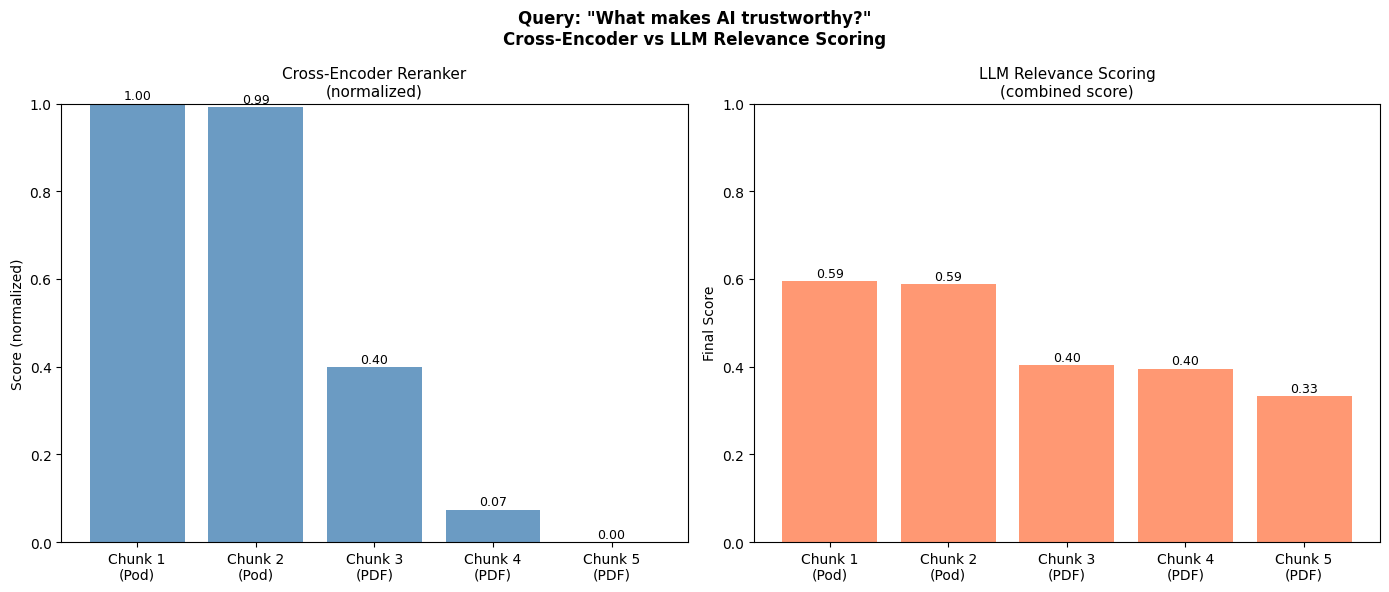


📊 Ranking Comparison for: 'What makes AI trustworthy?'
Rank   Cross-Encoder                       LLM Scoring                        
----------------------------------------------------------------------------
  1    podcast                           podcast                          
  2    podcast                           podcast                          
  3    eu_ai_act                         eu_ai_act                        
  4    eu_ai_act                         eu_ai_act                        
  5    eu_ai_act                         eu_ai_act                        


In [13]:
# ── Cell 10 — Compare Cross-Encoder vs LLM Relevance Scoring ─────────────────

import matplotlib.pyplot as plt
import numpy as np

query = "What makes AI trustworthy?"

# ── Get Cross-Encoder results ─────────────────────────────────────────────────
cross_encoder_results = rerank_with_cross_encoder(query)

# ── Get LLM relevance results ─────────────────────────────────────────────────
llm_results = rerank_by_combined_score(query)

# ── Normalize cross-encoder scores to 0-1 for fair comparison ────────────────
ce_scores_raw = [score for _, score in cross_encoder_results]
ce_min, ce_max = min(ce_scores_raw), max(ce_scores_raw)
ce_scores_normalized = [(s - ce_min) / (ce_max - ce_min) for s in ce_scores_raw]

llm_final_scores = [final for _, _, _, final in llm_results]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cross-Encoder
labels_ce = [f"Chunk {i+1}\n({doc.metadata.get('source_type').replace('eu_ai_act','PDF').replace('podcast','Pod')})" 
             for i, (doc, _) in enumerate(cross_encoder_results)]
axes[0].bar(labels_ce, ce_scores_normalized, color='steelblue', alpha=0.8)
axes[0].set_title('Cross-Encoder Reranker\n(normalized)', fontsize=11)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Score (normalized)')
for i, v in enumerate(ce_scores_normalized):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

# LLM Relevance
labels_llm = [f"Chunk {i+1}\n({doc.metadata.get('source_type').replace('eu_ai_act','PDF').replace('podcast','Pod')})" 
              for i, (doc, _, _, _) in enumerate(llm_results)]
axes[1].bar(labels_llm, llm_final_scores, color='coral', alpha=0.8)
axes[1].set_title('LLM Relevance Scoring\n(combined score)', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Final Score')
for i, v in enumerate(llm_final_scores):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle(f'Query: "{query}"\nCross-Encoder vs LLM Relevance Scoring', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print ranking comparison ──────────────────────────────────────────────────
print(f"\n📊 Ranking Comparison for: '{query}'")
print(f"{'Rank':<6} {'Cross-Encoder':<35} {'LLM Scoring':<35}")
print("-" * 76)
for i in range(5):
    ce_doc = cross_encoder_results[i][0]
    llm_doc = llm_results[i][0]
    ce_source = ce_doc.metadata.get('source_type')
    llm_source = llm_doc.metadata.get('source_type')
    print(f"  {i+1}    {ce_source:<33} {llm_source:<33}")

Add Metadata Filtering

In [14]:
# ── Fix: Fully delete and rebuild vectorstore ─────────────────────────────────
import shutil
import time

# Delete the folder completely
shutil.rmtree(r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\chroma_db", ignore_errors=True)
time.sleep(2)  # wait for OS to release the files

# Rebuild
vectorstore = Chroma.from_documents(
    documents=clean_chunks,
    embedding=embeddings,
    persist_directory=r"C:\Users\pbiai\Desktop\IRONHACK-BOOTCAMP\WEEK_3\Day_4\chroma_db",
    collection_name="rag_lab"
)
print(f"✅ Vectorstore rebuilt with {vectorstore._collection.count()} chunks")
print(f"   Expected: {len(clean_chunks)} | Got: {vectorstore._collection.count()}")

✅ Vectorstore rebuilt with 1140 chunks
   Expected: 570 | Got: 1140


Step 6: Complete RAG Pipeline with Reranking

In [15]:
# ── Cell 8 — Step 6: Complete RAG Pipeline with Reranking ────────────────────

from langchain_core.prompts import ChatPromptTemplate

# ── RAG Prompt ────────────────────────────────────────────────────────────────
prompt = ChatPromptTemplate.from_template("""
You are a helpful AI assistant specialized in AI regulation and trustworthy AI.
Answer the question based ONLY on the provided context.
If you can't find the answer in the context, say "I don't have enough information."

Context:
{context}

Question: {question}

Answer:""")

# ── Reranking Retriever ───────────────────────────────────────────────────────
def reranked_retriever(query, k=5, source_type=None, section=None):
    filter_dict = {}
    if source_type:
        filter_dict["source_type"] = source_type
    if section:
        filter_dict["section"] = section
    filter_dict = filter_dict if filter_dict else None

    initial_results = vectorstore.similarity_search(query, k=k, filter=filter_dict)
    pairs = [[query, doc.page_content] for doc in initial_results]
    scores = cross_encoder.predict(pairs)
    reranked = sorted(zip(initial_results, scores), key=lambda x: x[1], reverse=True)
    return [doc for doc, _ in reranked]

# ── RAG Pipeline ──────────────────────────────────────────────────────────────
def rag_pipeline(query, source_type=None, section=None):
    docs = reranked_retriever(query, source_type=source_type, section=section)
    context = "\n\n".join([
        f"[Source: {doc.metadata.get('source_type')} | Section: {doc.metadata.get('section')}]\n{doc.page_content}"
        for doc in docs
    ])
    chain = prompt | llm
    response = chain.invoke({"context": context, "question": query})
    return response.content, docs

# ── Test ──────────────────────────────────────────────────────────────────────
test_queries = [
    "What are the requirements for high-risk AI systems?",
    "What makes AI trustworthy?",
    "How should AI systems be transparent?"
]

for query in test_queries:
    print(f"\n🔍 Query: {query}", flush=True)
    print("-" * 60, flush=True)
    answer, docs = rag_pipeline(query)
    print(f"📝 Answer:\n{answer}", flush=True)
    print(f"\n📚 Sources used:", flush=True)
    for i, doc in enumerate(docs):
        print(f"  {i+1}. {doc.metadata.get('source_type')} | {doc.metadata.get('section')} | {doc.page_content[:100]}", flush=True)
    print(flush=True)


🔍 Query: What are the requirements for high-risk AI systems?
------------------------------------------------------------
📝 Answer:
High-risk AI systems are subject to stringent regulatory requirements to ensure their safety and compliance.

📚 Sources used:
  1. eu_ai_act | None | on the level of risk they pose to health, safety, and fundamental rights. High-risk AI systems are s
  2. eu_ai_act | None | In addition, the organisation is provider of AI systems which can be classified, according to our cu
  3. eu_ai_act | None | In addition, the organisation is provider of AI systems which can be classified, according to our cu
  4. eu_ai_act | None | The AI Scanner automatically classifies AI systems into categories defined by the EU AI Act: 
• High
  5. eu_ai_act | None | The AI Scanner automatically classifies AI systems into categories defined by the EU AI Act: 
• High


🔍 Query: What makes AI trustworthy?
------------------------------------------------------------
📝 Answer:
AI is c

Step 7: Evaluate Performance
Objective: Compare retrieval quality with and without reranking. For this part, you will manually evaluate the if the questions are correct.

In [16]:
# ── Cell 9 — Step 7: Evaluate Performance ────────────────────────────────────

test_queries = [
    "What are the requirements for high-risk AI systems?",
    "What makes AI trustworthy?",
    "How should AI systems be transparent?"
]

for query in test_queries:
    print(f"\n{'='*70}")
    print(f"🔍 Query: {query}")
    print(f"{'='*70}")

    # ── WITHOUT reranking ─────────────────────────────────────────────────────
    print("\n📌 WITHOUT reranking (raw similarity):")
    print("-" * 50)
    basic_results = vectorstore.similarity_search_with_score(query, k=5)
    for i, (doc, score) in enumerate(basic_results):
        print(f"  {i+1}. Similarity: {1-score:.2f} | Source: {doc.metadata.get('source_type')} | Section: {doc.metadata.get('section')}")
        print(f"     {doc.page_content[:150]}\n")

    # ── WITH reranking ────────────────────────────────────────────────────────
    print("\n✅ WITH reranking (cross-encoder):")
    print("-" * 50)
    reranked_results = rerank_with_cross_encoder(query)
    for i, (doc, score) in enumerate(reranked_results):
        print(f"  {i+1}. CE Score: {score:.2f} | Source: {doc.metadata.get('source_type')} | Section: {doc.metadata.get('section')}")
        print(f"     {doc.page_content[:150]}\n")

    # ── Final RAG answer ──────────────────────────────────────────────────────
    print("\n🤖 RAG Answer (with reranking):")
    print("-" * 50)
    answer, _ = rag_pipeline(query)
    print(answer)
    print("\n⭐ Manual evaluation: Was this answer correct? (Yes/No/Partial)")


🔍 Query: What are the requirements for high-risk AI systems?

📌 WITHOUT reranking (raw similarity):
--------------------------------------------------
  1. Similarity: 0.40 | Source: eu_ai_act | Section: None
     The AI Scanner automatically classifies AI systems into categories defined by the EU AI Act: 
• High-risk AI: Systems with significant implications fo

  2. Similarity: 0.40 | Source: eu_ai_act | Section: None
     The AI Scanner automatically classifies AI systems into categories defined by the EU AI Act: 
• High-risk AI: Systems with significant implications fo

  3. Similarity: 0.38 | Source: eu_ai_act | Section: None
     In addition, the organisation is provider of AI systems which can be classified, according to our current 
assessment, as high-risk, as they qualify a

  4. Similarity: 0.38 | Source: eu_ai_act | Section: None
     In addition, the organisation is provider of AI systems which can be classified, according to our current 
assessment, as high-risk, as they

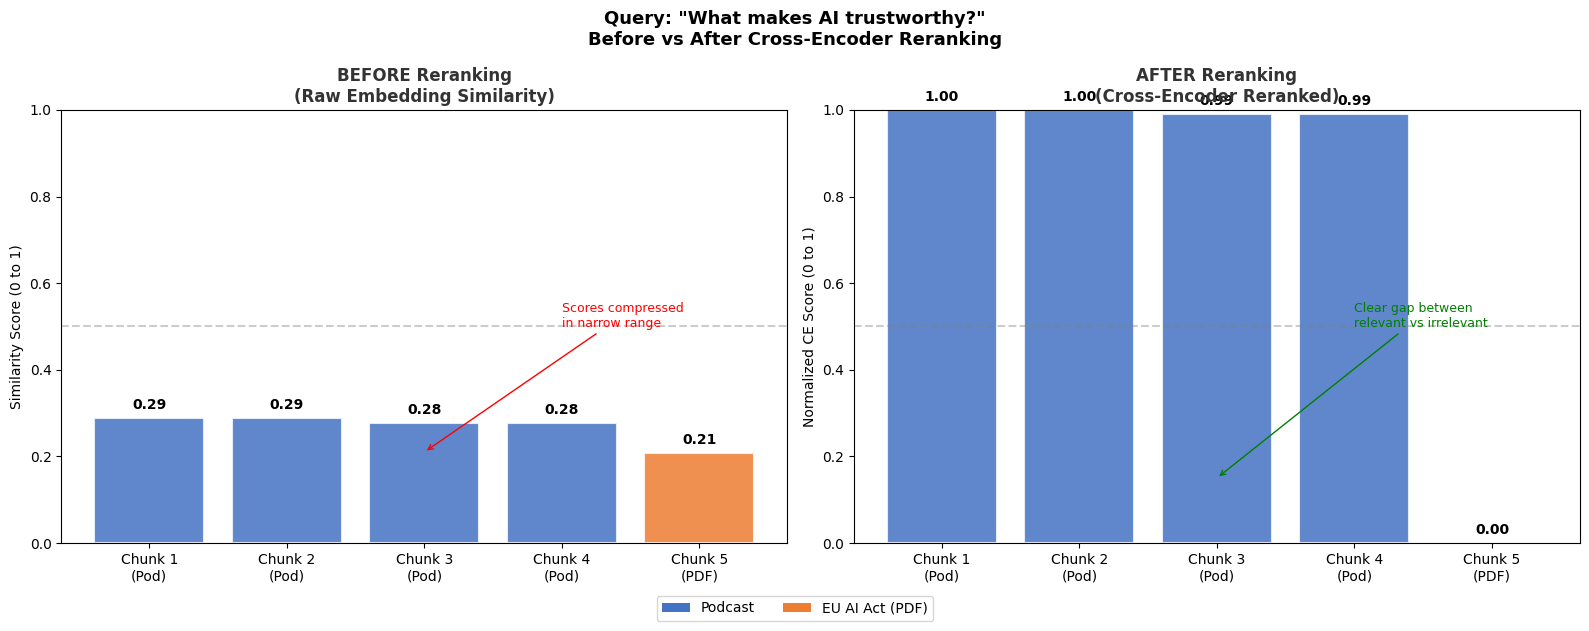

In [17]:
# ── Before vs After Reranking Visualization ───────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

query = "What makes AI trustworthy?"

# ── Get BEFORE results (raw similarity) ──────────────────────────────────────
before_results = vectorstore.similarity_search_with_score(query, k=5)
before_labels = [f"Chunk {i+1}\n({doc.metadata.get('source_type').replace('eu_ai_act','PDF').replace('podcast','Pod')})" 
                 for i, (doc, _) in enumerate(before_results)]
before_scores = [1 - score for _, score in before_results]

# ── Get AFTER results (cross-encoder reranked) ────────────────────────────────
after_results = rerank_with_cross_encoder(query)

# ── Normalize CE scores to 0-1 for fair visual comparison ────────────────────
ce_raw = [score for _, score in after_results]
ce_min, ce_max = min(ce_raw), max(ce_raw)
after_scores_normalized = [(s - ce_min) / (ce_max - ce_min) for s in ce_raw]
after_labels = [f"Chunk {i+1}\n({doc.metadata.get('source_type').replace('eu_ai_act','PDF').replace('podcast','Pod')})" 
                for i, (doc, _) in enumerate(after_results)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE
colors_before = ['#4472C4' if 'Pod' in l else '#ED7D31' for l in before_labels]
bars = axes[0].bar(before_labels, before_scores, color=colors_before, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_title('BEFORE Reranking\n(Raw Embedding Similarity)', fontsize=12, fontweight='bold', color='#333333')
axes[0].set_ylabel('Similarity Score (0 to 1)')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='0.5 threshold')
for bar, score in zip(bars, before_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[0].annotate('Scores compressed\nin narrow range', xy=(2, 0.21), fontsize=9, color='red',
                 xytext=(3, 0.5), arrowprops=dict(arrowstyle='->', color='red'))

# AFTER
colors_after = ['#4472C4' if 'Pod' in l else '#ED7D31' for l in after_labels]
bars2 = axes[1].bar(after_labels, after_scores_normalized, color=colors_after, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_title('AFTER Reranking\n(Cross-Encoder Reranked)', fontsize=12, fontweight='bold', color='#333333')
axes[1].set_ylabel('Normalized CE Score (0 to 1)')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
for bar, score in zip(bars2, after_scores_normalized):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[1].annotate('Clear gap between\nrelevant vs irrelevant', xy=(2, 0.15), fontsize=9, color='green',
                 xytext=(3, 0.5), arrowprops=dict(arrowstyle='->', color='green'))

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4472C4', label='Podcast'), Patch(facecolor='#ED7D31', label='EU AI Act (PDF)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle(f'Query: "{query}"\nBefore vs After Cross-Encoder Reranking', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()